# NFXP - Original Dynamic Demand Model - Monte Carlo Simulation

**Oliver Ovdal Eiberg Jørgensen & Solveig Røndal-Liniger** — Dynamic Programming, UCPH, Spring 2026


In [1]:
# Imports used across simulation, estimation, and plots.
import time
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## 1. Primitives and True Parameters Values

In [2]:
# Model dimensions
J     = 2       # brands
T     = 52      # periods per consumer
N     = 50_000  # consumers per panel
D_MAX = 25      # max duration index
DELTA = 0.95    # discount factor

# Price levels
BASE_PRICES   = np.array([11.95, 24.95])    # regular prices by brand
PROMO_DISC    = np.array([1.95,  15.67])    # promo discounts by brand
PROMO_ENTRY   = np.array([10 / 52, 6 / 52]) # weekly promo start prob.
PROMO_PERSIST = 0.0                         # promo persistence prob.

# True structural parameters (DGP)
# u(0) = α(ℓ) − β^dep*d; u(j) = α(j) − γ*p_j − β^sc*1{ℓ≠j}
ALPHA_TRUE    = np.array([0.0, 0.50])       # brand utilities; α_1 normalized
GAMMA_TRUE    = 0.05                        # price disutility
BETA_SC_TRUE  = 0.40                        # switching cost
BETA_DEP_TRUE = 0.275                       # depletion rate

# Monte Carlo
MC_REPS = 50                                  # MC replications
MC_SEED = 2024                                # master random seed
BURN_IN = 104                                 # discarded pre-sample periods
USE_COMMON_PROMOTIONS = True                  # shared market promo path
N_STARTS = 5                                  # pilot multi-start count
MC_N_STARTS = 3                               # MC multi-start count
START_SCALE = np.array([0.30, 0.02, 0.30, 0.08]) # start noise sd

# Choice indexing
# choice c = 0 means no purchase; c = j means buy brand j.
N_CHOICES = J + 1                             # choices: 0, 1, 2

# Parameter vector
PARAM_NAMES = ["alpha_2", "gamma", "beta_sc", "beta_dep"] # theta labels
THETA_TRUE = np.array([                       # true theta vector
    ALPHA_TRUE[1],                             # alpha_2
    GAMMA_TRUE,                                # price disutility
    BETA_SC_TRUE,                              # switching cost
    BETA_DEP_TRUE,                             # depletion rate
])
DEFAULT_THETA0 = np.array([0.25, 0.04, 0.25, 0.20]) # default start

print("True parameters:")
for n, v in zip(PARAM_NAMES, THETA_TRUE):
    print(f"  {n:<14} = {v}")
print(f"\nN_CHOICES={N_CHOICES}  |  BASE_PRICES={BASE_PRICES}  |  D_MAX={D_MAX}")

True parameters:
  alpha_2        = 0.5
  gamma          = 0.05
  beta_sc        = 0.4
  beta_dep       = 0.275

N_CHOICES=3  |  BASE_PRICES=[11.95 24.95]  |  D_MAX=25


## 2. Monte Carlo Design and Calibration

This table records the calibrated DGP primitives and simulation design in a LaTeX format that can be copied directly into the paper.

In [3]:
# Convert boolean settings into readable table entries.
def yes_no(value: bool) -> str:
    """Format booleans for paper tables."""
    return "Yes" if value else "No"


# Format parameter vectors for compact display in LaTeX tables.
def tuple_fmt(values, decimals: int = 3) -> str:
    """Format numerical vectors for LaTeX table cells."""
    return "(" + ", ".join(f"{float(v):.{decimals}f}" for v in values) + ")"


# Collect the calibrated DGP primitives for the first table.
panel_a_rows = [
    (r"Brands, $J$", f"{J}"),
    (r"Discount factor", f"{DELTA:.2f}"),
    (r"Duration cap, $D_{\max}$", f"{D_MAX}"),
    (r"True parameters $(\alpha_2,\gamma,\beta^{sc},\beta^{dep})$", tuple_fmt(THETA_TRUE, 3)),
    (r"Regular prices, $(p^0_1,p^0_2)$", tuple_fmt(BASE_PRICES, 2)),
    (r"Promotional discounts, $(\Delta p_1,\Delta p_2)$", tuple_fmt(PROMO_DISC, 2)),
    (r"Promotion entry probabilities", tuple_fmt(PROMO_ENTRY, 3)),
    (r"Promotion persistence", f"{PROMO_PERSIST:.3f}"),
]

# Collect the simulation and estimation choices for the second table.
panel_b_rows = [
    (r"Consumers per panel, $N$", f"{N:,}"),
    (r"Weeks per consumer, $T$", f"{T}"),
    (r"Burn-in weeks", f"{BURN_IN}"),
    (r"Monte Carlo replications, $R$", f"{MC_REPS}"),
    (r"Common weekly promotion path", yes_no(USE_COMMON_PROMOTIONS)),
    (r"NFXP starts per replication", f"{MC_N_STARTS}"),
    (r"Default starting value", tuple_fmt(DEFAULT_THETA0, 3)),
]

# Build a reusable two-column LaTeX table from label-value pairs.
def make_latex_table(rows, caption: str, label: str, first_col: str, second_col: str) -> str:
    """Return a compact two-column LaTeX table."""
    lines = [
        r"\begin{table}[H]",
        r"\centering",
        fr"\caption{{{caption}}}",
        fr"\label{{{label}}}",
        r"\begin{tabular}{ll}",
        r"\toprule",
        fr"{first_col} & {second_col} \\",
        r"\midrule",
    ]
    lines += [fr"{name} & {value} \\" for name, value in rows]
    lines += [
        r"\bottomrule",
        r"\end{tabular}",
        r"\end{table}",
    ]
    return "\n".join(lines)


# Generate the LaTeX table containing the calibrated DGP primitives.
mc_dgp_primitives_latex = make_latex_table(
    panel_a_rows,
    caption="Monte Carlo calibrated DGP primitives",
    label="tab:mc_dgp_primitives",
    first_col="DGP input",
    second_col="Calibration",
)
# Generate the LaTeX table containing the simulation design choices.
mc_sim_design_latex = make_latex_table(
    panel_b_rows,
    caption="Monte Carlo simulation and estimation design",
    label="tab:mc_sim_design",
    first_col="Design choice",
    second_col="Value",
)

# Print both tables so they can be copied directly into the paper.
print("% Table MC1: Calibrated DGP primitives")
print(mc_dgp_primitives_latex)
print("\n% Table MC2: Simulation and estimation design")
print(mc_sim_design_latex)


% Table MC1: Calibrated DGP primitives
\begin{table}[H]
\centering
\caption{Monte Carlo calibrated DGP primitives}
\label{tab:mc_dgp_primitives}
\begin{tabular}{ll}
\toprule
DGP input & Calibration \\
\midrule
Brands, $J$ & 2 \\
Discount factor & 0.95 \\
Duration cap, $D_{\max}$ & 25 \\
True parameters $(\alpha_2,\gamma,\beta^{sc},\beta^{dep})$ & (0.500, 0.050, 0.400, 0.275) \\
Regular prices, $(p^0_1,p^0_2)$ & (11.95, 24.95) \\
Promotional discounts, $(\Delta p_1,\Delta p_2)$ & (1.95, 15.67) \\
Promotion entry probabilities & (0.192, 0.115) \\
Promotion persistence & 0.000 \\
\bottomrule
\end{tabular}
\end{table}

% Table MC2: Simulation and estimation design
\begin{table}[H]
\centering
\caption{Monte Carlo simulation and estimation design}
\label{tab:mc_sim_design}
\begin{tabular}{ll}
\toprule
Design choice & Value \\
\midrule
Consumers per panel, $N$ & 50,000 \\
Weeks per consumer, $T$ & 52 \\
Burn-in weeks & 104 \\
Monte Carlo replications, $R$ & 50 \\
Common weekly promotion path 

## 3. Price Process

In [4]:
# Enumerate all 2^J joint promotion states as binary vectors.
promo_states = np.array(
    [[(s >> j) & 1 for j in range(J)] for s in range(2 ** J)],
    dtype=int
)
N_PROMO = len(promo_states)


# Combine the brand-level promotion processes into one joint transition matrix.
def make_promo_transition() -> np.ndarray:
    """Build the joint promotion transition matrix."""
    trans = np.empty((N_PROMO, N_PROMO))
    for s, curr in enumerate(promo_states):
        prob_on = np.where(curr == 1, PROMO_PERSIST, PROMO_ENTRY)
        for sp, nxt in enumerate(promo_states):
            trans[s, sp] = np.prod(np.where(nxt == 1, prob_on, 1.0 - prob_on))
    return trans


# Precompute transition probabilities and prices for every promotion state.
PROMO_TRANS = make_promo_transition()
PRICE_BY_PROMO = BASE_PRICES - PROMO_DISC * promo_states


# Find the long-run probabilities used to initialize the promotion process.
def stationary_distribution(trans: np.ndarray) -> np.ndarray:
    """Stationary distribution of a finite Markov transition matrix."""
    eigvals, eigvecs = np.linalg.eig(trans.T)
    idx = np.argmin(np.abs(eigvals - 1.0))
    stat = np.real(eigvecs[:, idx])
    stat = stat / stat.sum()
    if np.any(stat < 0):
        stat = np.abs(stat)
        stat = stat / stat.sum()
    return stat


# Store the long-run distribution for later simulation draws.
PROMO_STATIONARY = stationary_distribution(PROMO_TRANS)


# Simulate a shared weekly promotion sequence for the full market.
def draw_common_promo_path(n_periods: int, rng, initial_state: int = None) -> np.ndarray:
    """Draw one market-wide promotion path shared by all consumers."""
    path = np.empty(n_periods, dtype=int)
    e_idx = int(initial_state) if initial_state is not None else int(
        rng.choice(N_PROMO, p=PROMO_STATIONARY)
    )
    for t in range(n_periods):
        path[t] = e_idx
        e_idx = int(rng.choice(N_PROMO, p=PROMO_TRANS[e_idx]))
    return path


# Print the price combinations implied by the promotion states.
print("Unit prices by promotion state:")
for s, e in enumerate(promo_states):
    p = PRICE_BY_PROMO[s]
    e_tuple = tuple(int(v) for v in e)
    print(f"  State {s}: e={e_tuple}  p={p}")


Unit prices by promotion state:
  State 0: e=(0, 0)  p=[11.95 24.95]
  State 1: e=(1, 0)  p=[10.   24.95]
  State 2: e=(0, 1)  p=[11.95  9.28]
  State 3: e=(1, 1)  p=[10.    9.28]


## 4. Utility Function

In [5]:
# Evaluate deterministic utility for a single action in a given consumer state.
def flow_util(choice, last_brand, duration, e_idx,
              alpha, gamma, beta_sc, beta_dep) -> float:
    """Deterministic period utility for one state-choice pair."""
    l = last_brand - 1
    prices = BASE_PRICES - PROMO_DISC * promo_states[e_idx]

    # Retain inventory utility when the consumer does not purchase.
    if choice == 0:
        return alpha[l] - beta_dep[l] * duration

    # Subtract price disutility and any switching cost for a purchase.
    j = choice - 1
    return alpha[j] - gamma * prices[j] - beta_sc[l, j]


## 5. Inner Loop: Value Function Iteration (VFI)

In [6]:
# Solve for the expected value function by iterating on the Bellman equation.
def solve_vfi(alpha,
              gamma,
              beta_sc,
              beta_dep,
              tol: float = 1e-10,
              max_iter: int = 2_000) -> np.ndarray:
    """Solve the Bellman equation for the homogeneous model."""
    # Set up duration states and the capped transition after no purchase.
    duration_idx = np.arange(D_MAX + 1)
    duration = duration_idx + 1.0
    next_duration = np.minimum(duration_idx + 1, D_MAX)

    # Precompute no-purchase utility and initialize the value arrays.
    no_purchase_util = alpha[:, None] - beta_dep[:, None] * duration[None, :]
    Q = np.empty((J, D_MAX + 1, N_PROMO, N_CHOICES))
    V = np.zeros((J, D_MAX + 1, N_PROMO))

    # Iterate until the value function reaches the requested tolerance.
    for _ in range(max_iter):
        # Average next-period values over possible promotion states.
        EV = (V.reshape(J * (D_MAX + 1), N_PROMO) @ PROMO_TRANS.T
              ).reshape(J, D_MAX + 1, N_PROMO)

        # Compute the action value of retaining the current inventory.
        Q[..., 0] = no_purchase_util[:, :, None] + DELTA * EV[:, next_duration, :]

        # Compute the action value of purchasing each available brand.
        for j_idx in range(J):
            Q[..., j_idx + 1] = (
                alpha[j_idx]
                - gamma * PRICE_BY_PROMO[:, j_idx][None, None, :]
                - beta_sc[:, j_idx][:, None, None]
                + DELTA * EV[j_idx, 0, :][None, None, :]
            )

        # Apply the log-sum-exp formula to update expected values stably.
        q_max = Q.max(axis=3)
        V_new = q_max + np.log(np.exp(Q - q_max[..., None]).sum(axis=3))

        # Stop once successive value-function iterates are sufficiently close.
        if np.max(np.abs(V_new - V)) < tol:
            return V_new
        V = V_new

    return V


## 6. Conditional Choice Probabilities (CCPs)

In [7]:
# Convert a solved value function into conditional choice probabilities.
def compute_ccps(V,
                 alpha,
                 gamma,
                 beta_sc,
                 beta_dep) -> np.ndarray:
    """Compute CCPs from a solved value function."""
    # Set up duration states and the capped transition after no purchase.
    duration_idx = np.arange(D_MAX + 1)
    duration = duration_idx + 1.0
    next_duration = np.minimum(duration_idx + 1, D_MAX)

    # Average next-period values over possible promotion states.
    EV = (V.reshape(J * (D_MAX + 1), N_PROMO) @ PROMO_TRANS.T
          ).reshape(J, D_MAX + 1, N_PROMO)

    # Compute the action value of retaining the current inventory.
    Q = np.empty((J, D_MAX + 1, N_PROMO, N_CHOICES))
    no_purchase_util = alpha[:, None] - beta_dep[:, None] * duration[None, :]
    Q[..., 0] = no_purchase_util[:, :, None] + DELTA * EV[:, next_duration, :]

    # Compute the action value of purchasing each available brand.
    for j_idx in range(J):
        Q[..., j_idx + 1] = (
            alpha[j_idx]
            - gamma * PRICE_BY_PROMO[:, j_idx][None, None, :]
            - beta_sc[:, j_idx][:, None, None]
            + DELTA * EV[j_idx, 0, :][None, None, :]
        )

    # Normalize exponentiated action values into choice probabilities.
    weights = np.exp(Q - Q.max(axis=3, keepdims=True))
    return weights / weights.sum(axis=3, keepdims=True)


## 7. Data Simulation

In [8]:
# Draw one categorical outcome from each row of choice probabilities.
def _sample_rows(rng,
                 row_probs: np.ndarray) -> np.ndarray:
    """Vectorized categorical draw: one observation per row."""
    u = rng.random(len(row_probs))
    cumsum = np.cumsum(row_probs, axis=1)
    return (u[:, None] > cumsum).sum(axis=1)


# Simulate a homogeneous consumer panel from the model-implied CCPs.
def simulate_panel(P_true: np.ndarray,
                   n_consumers: int = N,
                   n_periods: int = T,
                   seed=None,
                   common_promotions: bool = USE_COMMON_PROMOTIONS,
                   burn_in: int = BURN_IN,
                   promo_path: np.ndarray = None,
                   return_promo_path: bool = False) -> dict:
    """Simulate a homogeneous consumer panel from CCPs."""
    rng = np.random.default_rng(seed)
    total_periods = burn_in + n_periods

    # Allocate observed-sample arrays and initialize consumer states.
    Y = np.zeros((n_consumers, n_periods), dtype=int)
    L = np.zeros((n_consumers, n_periods), dtype=int)
    D = np.zeros((n_consumers, n_periods), dtype=int)
    E_IDX = np.zeros((n_consumers, n_periods), dtype=int)

    ell = rng.integers(1, J + 1, size=n_consumers)
    dur = np.zeros(n_consumers, dtype=int)

    # Set up either one market-wide promotion path or individual paths.
    if common_promotions:
        if promo_path is None:
            promo_path = draw_common_promo_path(total_periods, rng)
        else:
            promo_path = np.asarray(promo_path, dtype=int)
            if len(promo_path) < total_periods:
                raise ValueError("promo_path must cover burn_in + n_periods")
    else:
        e_idx = rng.choice(N_PROMO, size=n_consumers, p=PROMO_STATIONARY)

    # Simulate the burn-in and observed periods one week at a time.
    for tau in range(total_periods):
        if common_promotions:
            e_lookup = np.full(n_consumers, promo_path[tau], dtype=int)
        else:
            e_lookup = e_idx

        if tau >= burn_in:
            t = tau - burn_in
            L[:, t] = ell
            D[:, t] = dur
            E_IDX[:, t] = e_lookup

        probs = P_true[ell - 1, np.minimum(dur, D_MAX), e_lookup, :]
        y = _sample_rows(rng, probs)
        if tau >= burn_in:
            Y[:, t] = y

        bought = y > 0
        ell = np.where(bought, y, ell)
        dur = np.where(bought, 0, np.minimum(dur + 1, D_MAX))
        if not common_promotions:
            e_idx = _sample_rows(rng, PROMO_TRANS[e_idx])

    # Return the simulated panel and optionally its observed promotion path.
    out = {"Y": Y, "L": L, "D": D, "E_IDX": E_IDX}
    if return_promo_path and common_promotions:
        out["PROMO_PATH"] = promo_path[burn_in:burn_in + n_periods]
    return out


# Simulate a stress-test panel with latent heterogeneity in brand utility.
def simulate_heterogeneous_panel(alpha2_values=None,
                                 type_shares=None,
                                 n_consumers: int = N,
                                 n_periods: int = T,
                                 seed=None,
                                 common_promotions: bool = USE_COMMON_PROMOTIONS,
                                 burn_in: int = BURN_IN) -> dict:
    """Stress-test DGP with unobserved heterogeneity in alpha_2."""
    rng = np.random.default_rng(seed)
    # Set the type-specific alpha_2 values used in the stress test.
    if alpha2_values is None:
        alpha2_values = np.array([THETA_TRUE[0] - 0.30, THETA_TRUE[0] + 0.30])
    else:
        alpha2_values = np.asarray(alpha2_values, dtype=float)

    # Set and normalize the population shares for the latent types.
    if type_shares is None:
        type_shares = np.ones(len(alpha2_values)) / len(alpha2_values)
    else:
        type_shares = np.asarray(type_shares, dtype=float)
        type_shares = type_shares / type_shares.sum()

    # Draw consumer types and prepare a shared promotion environment if needed.
    type_ids = rng.choice(len(alpha2_values), size=n_consumers, p=type_shares)
    total_periods = burn_in + n_periods
    promo_path = draw_common_promo_path(total_periods, rng) if common_promotions else None

    # Allocate arrays for the combined heterogeneous panel.
    out = {
        "Y": np.zeros((n_consumers, n_periods), dtype=int),
        "L": np.zeros((n_consumers, n_periods), dtype=int),
        "D": np.zeros((n_consumers, n_periods), dtype=int),
        "E_IDX": np.zeros((n_consumers, n_periods), dtype=int),
        "TYPE": type_ids,
    }

    # Solve and simulate the model separately for each latent type.
    for type_id, alpha2 in enumerate(alpha2_values):
        idx = np.where(type_ids == type_id)[0]
        if len(idx) == 0:
            continue
        theta_type = THETA_TRUE.copy()
        theta_type[0] = alpha2
        a_type, g_type, sc_type, dep_type = unpack(theta_type)
        V_type = solve_vfi(a_type, g_type, sc_type, dep_type)
        P_type = compute_ccps(V_type, a_type, g_type, sc_type, dep_type)
        data_type = simulate_panel(
            P_type,
            n_consumers=len(idx),
            n_periods=n_periods,
            seed=int(rng.integers(0, 1_000_000)),
            common_promotions=common_promotions,
            burn_in=burn_in,
            promo_path=promo_path,
        )
        for key in ["Y", "L", "D", "E_IDX"]:
            out[key][idx, :] = data_type[key]

    # Attach the observed common promotion path when one was used.
    if common_promotions:
        out["PROMO_PATH"] = promo_path[burn_in:burn_in + n_periods]
    return out


## 8. Log-Likelihood and NFXP

In [9]:
# Evaluate the full panel log-likelihood from realized choice probabilities.
def log_likelihood(data: dict,
                   P: np.ndarray) -> float:
    """Summed log-likelihood over all observations."""
    Y, L, D, E = data["Y"], data["L"], data["D"], data["E_IDX"]
    probs = P[L - 1, D, E, Y]
    return float(np.sum(np.log(np.maximum(probs, 1e-300))))


# Collapse repeated observations into state-choice counts for faster estimation.
def state_choice_counts(data: dict) -> np.ndarray:
    """Aggregate panel observations by state and realized choice."""
    counts = np.zeros((J, D_MAX + 1, N_PROMO, N_CHOICES), dtype=float)
    np.add.at(
        counts,
        (
            data["L"].ravel() - 1,
            data["D"].ravel(),
            data["E_IDX"].ravel(),
            data["Y"].ravel(),
        ),
        1.0,
    )
    return counts


# Evaluate the same log-likelihood using aggregated state-choice counts.
def log_likelihood_counts(counts: np.ndarray,
                          P: np.ndarray) -> float:
    """Summed log-likelihood using state-choice counts."""
    return float(np.sum(counts * np.log(np.maximum(P, 1e-300))))


# Apply the common depletion parameter to every brand.
def make_beta_dep(beta_dep: float) -> np.ndarray:
    """Expand common depletion rate to brands."""
    return np.full(J, float(beta_dep))


# Expand the common switching cost into a symmetric brand-to-brand matrix.
def make_beta_sc(beta_sc: float) -> np.ndarray:
    """Build symmetric switching-cost matrix."""
    mat = np.full((J, J), float(beta_sc))
    np.fill_diagonal(mat, 0.0)
    return mat


# Convert the compact parameter vector into the objects used by the model.
def unpack(theta: np.ndarray):
    """Unpack theta = [alpha_2, gamma, beta_sc, beta_dep]."""
    alpha = np.array([0.0, theta[0]])
    gamma = float(theta[1])
    beta_sc = make_beta_sc(theta[2])
    beta_dep = make_beta_dep(theta[3])
    return alpha, gamma, beta_sc, beta_dep


# Flag parameter vectors that violate the model's sign restrictions.
def invalid_theta(theta: np.ndarray) -> bool:
    """Check sign restrictions."""
    theta = np.asarray(theta)
    return (theta[1] <= 0.0) or np.any(theta[2:] < 0.0)


# Solve the inner dynamic program and return the outer-loop objective value.
def nfxp_objective(theta: np.ndarray, data_or_counts) -> float:
    """Solve inner DP and return negative log-likelihood."""
    if invalid_theta(theta):
        return 1e12 + 1e8 * float(np.sum(np.minimum(theta[1:], 0.0) ** 2))
    counts = state_choice_counts(data_or_counts) if isinstance(data_or_counts, dict) else data_or_counts
    alpha, gamma, beta_sc, beta_dep = unpack(theta)
    V = solve_vfi(alpha, gamma, beta_sc, beta_dep)
    P = compute_ccps(V, alpha, gamma, beta_sc, beta_dep)
    return -log_likelihood_counts(counts, P)


# Estimate one NFXP solution from a specified starting value.
def estimate_nfxp(data_or_counts,
                  theta0: np.ndarray = None,
                  verbose: bool = False):
    """Estimate the model with NFXP (Nelder-Mead)."""
    if theta0 is None:
        theta0 = DEFAULT_THETA0.copy()
    counts = state_choice_counts(data_or_counts) if isinstance(data_or_counts, dict) else data_or_counts
    return minimize(
        fun=nfxp_objective,
        x0=theta0,
        args=(counts,),
        method="Nelder-Mead",
        options={"maxiter": 10_000, "xatol": 1e-5, "fatol": 1e-5,
                 "disp": verbose, "adaptive": True},
    )


# Generate dispersed admissible starting values for robust optimization.
def make_starting_values(theta_center: np.ndarray = None,
                         n_starts: int = N_STARTS,
                         seed=None) -> list[np.ndarray]:
    """Create dispersed but admissible starting values."""
    rng = np.random.default_rng(seed)
    center = DEFAULT_THETA0.copy() if theta_center is None else np.asarray(theta_center, dtype=float)
    starts = [center.copy()]
    for _ in range(max(n_starts - 1, 0)):
        draw = center + rng.normal(0.0, START_SCALE, size=len(center))
        draw[1:] = np.maximum(draw[1:], 1e-4)
        starts.append(draw)
    return starts


# Run NFXP from several starting values and retain the best converged result.
def estimate_nfxp_multistart(data_or_counts,
                             theta_center: np.ndarray = None,
                             n_starts: int = N_STARTS,
                             seed=None,
                             verbose: bool = False):
    """Run NFXP from several starts and keep the best result."""
    counts = state_choice_counts(data_or_counts) if isinstance(data_or_counts, dict) else data_or_counts
    results = []
    for start_id, theta0 in enumerate(make_starting_values(theta_center, n_starts, seed), start=1):
        res = estimate_nfxp(counts, theta0=theta0, verbose=verbose)
        res.start_id = start_id
        res.theta0 = theta0
        results.append(res)

    successful = [r for r in results if r.success]
    candidates = successful if successful else results
    best = min(candidates, key=lambda r: r.fun)
    return best, results


# Trace the objective around an estimate for one selected parameter.
def likelihood_profile(data_or_counts,
                       center_theta: np.ndarray,
                       param_idx: int,
                       grid: np.ndarray) -> pd.DataFrame:
    """One-dimensional likelihood profile."""
    counts = state_choice_counts(data_or_counts) if isinstance(data_or_counts, dict) else data_or_counts
    base_nll = nfxp_objective(center_theta, counts)
    rows = []
    for value in grid:
        theta = center_theta.copy()
        theta[param_idx] = value
        nll = nfxp_objective(theta, counts)
        rows.append({
            "param": PARAM_NAMES[param_idx],
            "value": value,
            "delta_nll": nll - base_nll,
        })
    return pd.DataFrame(rows)


# Build local likelihood profiles for every estimated parameter.
def profile_all_parameters(data_or_counts,
                           center_theta: np.ndarray,
                           rel_width: float = 0.40,
                           n_grid: int = 9) -> pd.DataFrame:
    """Likelihood profiles around a reference estimate."""
    frames = []
    for idx, value in enumerate(center_theta):
        width = rel_width * max(abs(value), 0.05)
        lo = value - width if idx == 0 else max(1e-4, value - width)
        hi = value + width
        grid = np.linspace(lo, hi, n_grid)
        frames.append(likelihood_profile(data_or_counts, center_theta, idx, grid))
    return pd.concat(frames, ignore_index=True)


# Approximate the objective Hessian with central finite differences.
def numerical_hessian(func,
                      theta: np.ndarray,
                      step_scale: float = 1e-4,
                      min_step: float = 1e-5) -> np.ndarray:
    """Central-difference Hessian for a scalar objective."""
    theta = np.asarray(theta, dtype=float)
    k = len(theta)
    h = np.maximum(step_scale * np.maximum(np.abs(theta), 1.0), min_step)
    H = np.empty((k, k), dtype=float)
    f0 = func(theta)

    # Approximate the diagonal second derivatives.
    for i in range(k):
        ei = np.zeros(k)
        ei[i] = h[i]
        H[i, i] = (func(theta + ei) - 2.0 * f0 + func(theta - ei)) / (h[i] ** 2)

    # Approximate the cross derivatives and mirror the symmetric entries.
    for i in range(k):
        for j in range(i + 1, k):
            ei = np.zeros(k)
            ej = np.zeros(k)
            ei[i] = h[i]
            ej[j] = h[j]
            H_ij = (
                func(theta + ei + ej)
                - func(theta + ei - ej)
                - func(theta - ei + ej)
                + func(theta - ei - ej)
            ) / (4.0 * h[i] * h[j])
            H[i, j] = H_ij
            H[j, i] = H_ij

    return H


# Derive approximate standard errors and confidence intervals from the Hessian.
def estimate_standard_errors(data_or_counts,
                             theta_hat: np.ndarray,
                             step_scale: float = 1e-4) -> tuple[pd.DataFrame, np.ndarray]:
    """Approximate MLE standard errors from the Hessian."""
    counts = state_choice_counts(data_or_counts) if isinstance(data_or_counts, dict) else data_or_counts
    objective = lambda th: nfxp_objective(th, counts)
    H = numerical_hessian(objective, theta_hat, step_scale=step_scale)
    H = 0.5 * (H + H.T)

    # Invert the Hessian, using a pseudo-inverse if it is singular.
    try:
        cov = np.linalg.inv(H)
        covariance_method = "inverse Hessian"
    except np.linalg.LinAlgError:
        cov = np.linalg.pinv(H)
        covariance_method = "pseudo-inverse Hessian"

    # Convert the covariance matrix into standard errors and inference statistics.
    diag = np.diag(cov)
    se = np.full_like(diag, np.nan, dtype=float)
    positive_diag = diag > 0
    se[positive_diag] = np.sqrt(diag[positive_diag])
    z = theta_hat / se
    ci_lo = theta_hat - 1.96 * se
    ci_hi = theta_hat + 1.96 * se
    eig_min = float(np.linalg.eigvalsh(H).min())

    se_table = pd.DataFrame({
        "param": PARAM_NAMES,
        "estimate": theta_hat,
        "std_error": se,
        "z_stat": z,
        "ci95_lo": ci_lo,
        "ci95_hi": ci_hi,
    })
    se_table.attrs["covariance_method"] = covariance_method
    se_table.attrs["hessian_min_eigenvalue"] = eig_min
    return se_table, H


# Compare observed outcomes with model predictions across key dimensions.
def model_fit_tables(data_or_counts,
                     theta_hat: np.ndarray,
                     duration_tail_start: int = 8) -> dict[str, pd.DataFrame]:
    """Observed-vs-predicted fit summaries."""
    counts = state_choice_counts(data_or_counts) if isinstance(data_or_counts, dict) else data_or_counts
    alpha, gamma, beta_sc, beta_dep = unpack(theta_hat)
    V_hat = solve_vfi(alpha, gamma, beta_sc, beta_dep)
    P_hat = compute_ccps(V_hat, alpha, gamma, beta_sc, beta_dep)
    state_counts = counts.sum(axis=3)

    # Summarize purchase behavior across duration bins.
    duration_rows = []
    duration_bins = [(d, d, str(d + 1)) for d in range(duration_tail_start - 1)]
    if duration_tail_start <= D_MAX + 1:
        duration_bins.append((duration_tail_start - 1, D_MAX, f"{duration_tail_start}+"))

    for d_lo, d_hi, label in duration_bins:
        denom = state_counts[:, d_lo:d_hi + 1, :].sum()
        if denom <= 0:
            continue
        obs_no = counts[:, d_lo:d_hi + 1, :, 0].sum() / denom
        pred_no = (
            state_counts[:, d_lo:d_hi + 1, :] * P_hat[:, d_lo:d_hi + 1, :, 0]
        ).sum() / denom
        obs_purchase = counts[:, d_lo:d_hi + 1, :, 1:].sum() / denom
        pred_purchase = (
            state_counts[:, d_lo:d_hi + 1, :] * P_hat[:, d_lo:d_hi + 1, :, 1:].sum(axis=3)
        ).sum() / denom
        duration_rows.append({
            "duration": label,
            "duration_mid": 0.5 * (d_lo + d_hi) + 1,
            "n_obs": denom,
            "obs_no_purchase": obs_no,
            "pred_no_purchase": pred_no,
            "obs_purchase_hazard": obs_purchase,
            "pred_purchase_hazard": pred_purchase,
        })
    duration_fit = pd.DataFrame(duration_rows)

    # Summarize observed and predicted choice shares by promotion state.
    promo_rows = []
    choice_labels = ["no_purchase"] + [f"brand_{j}" for j in range(1, J + 1)]
    for e_idx, e_vec in enumerate(promo_states):
        denom = state_counts[:, :, e_idx].sum()
        if denom <= 0:
            continue
        for c, label in enumerate(choice_labels):
            obs_share = counts[:, :, e_idx, c].sum() / denom
            pred_share = (state_counts[:, :, e_idx] * P_hat[:, :, e_idx, c]).sum() / denom
            promo_rows.append({
                "promo_state": str(tuple(int(v) for v in e_vec)),
                "choice": label,
                "n_obs": denom,
                "obs_share": obs_share,
                "pred_share": pred_share,
            })
    promo_choice_fit = pd.DataFrame(promo_rows)

    # Summarize purchase and switching rates across the full sample.
    obs_switch_all = 0.0
    pred_switch_all = 0.0
    obs_purchase = counts[..., 1:].sum()
    pred_purchase = (state_counts * P_hat[..., 1:].sum(axis=3)).sum()
    total_obs = counts.sum()
    for l_idx in range(J):
        for j_idx in range(J):
            if j_idx == l_idx:
                continue
            choice_idx = j_idx + 1
            obs_switch_all += counts[l_idx, :, :, choice_idx].sum()
            pred_switch_all += (state_counts[l_idx, :, :] * P_hat[l_idx, :, :, choice_idx]).sum()

    switching_fit = pd.DataFrame([
        {
            "metric": "purchase_rate",
            "observed": obs_purchase / total_obs,
            "predicted": pred_purchase / total_obs,
        },
        {
            "metric": "switch_rate_all_observations",
            "observed": obs_switch_all / total_obs,
            "predicted": pred_switch_all / total_obs,
        },
        {
            "metric": "switch_rate_given_purchase",
            "observed": obs_switch_all / obs_purchase if obs_purchase > 0 else np.nan,
            "predicted": pred_switch_all / pred_purchase if pred_purchase > 0 else np.nan,
        },
    ])

    return {
        "duration_fit": duration_fit,
        "promo_choice_fit": promo_choice_fit,
        "switching_fit": switching_fit,
    }

## 9. Pilot — Single Panel

Verify that VFI converges, the simulation looks reasonable, and that NFXP recovers the true parameters from a single panel.

In [10]:
# Solve the model at the true DGP parameters to obtain simulation CCPs.
print("Step 1: Solving DP at true parameters...")
a0, g0, sc0, dep0 = unpack(THETA_TRUE)
V_true = solve_vfi(a0, g0, sc0, dep0)
P_true = compute_ccps(V_true, a0, g0, sc0, dep0)
print("  VFI converged.")

# Simulate one pilot panel and report its main choice and promotion shares.
print(f"\nStep 2: Simulating panel (N={N}, T={T}, burn-in={BURN_IN})...")
data_pilot = simulate_panel(P_true, seed=42, return_promo_path=True)
Y = data_pilot["Y"]
print(f"  No purchase: {(Y == 0).mean():.1%}")
for j in range(1, J + 1):
    print(f"  Brand {j}:     {(Y == j).mean():.1%}")

promo_counts = np.bincount(data_pilot["E_IDX"].ravel(), minlength=N_PROMO) / data_pilot["E_IDX"].size
print(f"  Promotion-state shares: {np.round(promo_counts, 3)}")

# Estimate the pilot panel from several starting values and time the routine.
print("\nStep 3: Estimating with NFXP multi-start...")
t0 = time.perf_counter()
res_pilot, pilot_starts = estimate_nfxp_multistart(
    data_pilot, theta_center=DEFAULT_THETA0, n_starts=N_STARTS, seed=4242
)
t1 = time.perf_counter() - t0
print(
    f"  Time: {t1:.1f}s  |  Best converged: {res_pilot.success}  "
    f"|  Best start: {res_pilot.start_id}/{N_STARTS}  |  Iterations: {res_pilot.nit}"
)
print(f"  Successful starts: {sum(r.success for r in pilot_starts)}/{len(pilot_starts)}")

# Compare the recovered pilot estimates with the true parameter values.
print("\n" + "─" * 55)
df_pilot = pd.DataFrame({
    "Parameter": PARAM_NAMES,
    "True": THETA_TRUE,
    "NFXP": res_pilot.x,
    "Bias": res_pilot.x - THETA_TRUE,
})
print(df_pilot.to_string(index=False, float_format=lambda x: f"{x:+.4f}"))

# Inspect local likelihood profiles as a simple identification diagnostic.
profiles_pilot = profile_all_parameters(data_pilot, res_pilot.x, rel_width=0.30, n_grid=7)
profile_width = profiles_pilot.groupby("param")["delta_nll"].max().reset_index(name="max_delta_nll")
print("\nLikelihood profile width around the pilot estimate:")
print(profile_width.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

# Approximate standard errors and confidence intervals from the numerical Hessian.
print("\nApproximate standard errors from numerical Hessian:")
se_pilot, hessian_pilot = estimate_standard_errors(data_pilot, res_pilot.x)
print(f"  Covariance method: {se_pilot.attrs['covariance_method']}")
print(f"  Hessian min eigenvalue: {se_pilot.attrs['hessian_min_eigenvalue']:.4e}")
print(se_pilot.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Compare observed and predicted outcomes across the model-fit summaries.
print("\nObserved vs predicted fit: duration profiles")
fit_pilot = model_fit_tables(data_pilot, res_pilot.x)
duration_cols = ["duration", "n_obs", "obs_no_purchase", "pred_no_purchase",
                 "obs_purchase_hazard", "pred_purchase_hazard"]
print(fit_pilot["duration_fit"][duration_cols].to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\nObserved vs predicted fit: choice shares by promotion state")
print(fit_pilot["promo_choice_fit"].to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\nObserved vs predicted fit: purchase and switching rates")
print(fit_pilot["switching_fit"].to_string(index=False, float_format=lambda x: f"{x:.4f}"))

Step 1: Solving DP at true parameters...
  VFI converged.

Step 2: Simulating panel (N=50000, T=52, burn-in=104)...
  No purchase: 44.4%
  Brand 1:     23.0%
  Brand 2:     32.7%
  Promotion-state shares: [0.75  0.173 0.077 0.   ]

Step 3: Estimating with NFXP multi-start...
  Time: 32.4s  |  Best converged: True  |  Best start: 4/5  |  Iterations: 168
  Successful starts: 5/5

───────────────────────────────────────────────────────
Parameter    True    NFXP    Bias
  alpha_2 +0.5000 +0.5001 +0.0001
    gamma +0.0500 +0.0500 +0.0000
  beta_sc +0.4000 +0.4006 +0.0006
 beta_dep +0.2750 +0.2746 -0.0004

Likelihood profile width around the pilot estimate:
   param  max_delta_nll
 alpha_2       18756.61
beta_dep       12225.17
 beta_sc        3321.32
   gamma       22693.83

Approximate standard errors from numerical Hessian:
  Covariance method: inverse Hessian
  Hessian min eigenvalue: 3.2843e+05
   param  estimate  std_error   z_stat  ci95_lo  ci95_hi
 alpha_2    0.5001     0.0012 418.10

## 10. Monte Carlo

For each replication:
1. Draw one market-wide weekly promotion path and simulate a new panel after burn-in
2. Estimate the model with NFXP from several dispersed starting values
3. Record estimates, bias, RMSE, convergence, and multi-start diagnostics

In [11]:
# Run repeated simulations and estimations to assess parameter recovery.
def run_monte_carlo(n_reps: int = MC_REPS,
                    seed: int = MC_SEED,
                    n_starts: int = MC_N_STARTS,
                    common_promotions: bool = USE_COMMON_PROMOTIONS,
                    burn_in: int = BURN_IN):
    # Create reproducible seeds for the individual Monte Carlo replications.
    rng_master = np.random.default_rng(seed)
    rep_seeds = rng_master.integers(0, 1_000_000, size=n_reps)

    # Solve the model once at the true parameters for repeated simulation.
    a_t, g_t, sc_t, dep_t = unpack(THETA_TRUE)
    V_t = solve_vfi(a_t, g_t, sc_t, dep_t)
    P_t = compute_ccps(V_t, a_t, g_t, sc_t, dep_t)

    print(f"MC  |  J={J}, T={T}, N={N}, D_MAX={D_MAX}, reps={n_reps}, starts={n_starts}")
    print(f"DGP: β^sc={BETA_SC_TRUE:.3f}, β^dep={BETA_DEP_TRUE:.3f}")
    print(f"Simulation: common_promotions={common_promotions}, burn_in={burn_in}\n")

    # Simulate and estimate the model independently in each replication.
    rows = []
    for rep in range(1, n_reps + 1):
        data = simulate_panel(
            P_t,
            n_consumers=N,
            n_periods=T,
            seed=int(rep_seeds[rep - 1]),
            common_promotions=common_promotions,
            burn_in=burn_in,
        )

        # Estimate the simulated panel from several starting values.
        t0 = time.perf_counter()
        r, starts = estimate_nfxp_multistart(
            data,
            theta_center=DEFAULT_THETA0,
            n_starts=n_starts,
            seed=int(rep_seeds[rep - 1]) + 999,
        )
        t1 = time.perf_counter() - t0

        # Record convergence diagnostics for the multi-start optimization.
        n_success = sum(s.success for s in starts)
        fun_values = np.array([s.fun for s in starts])
        local_gap = np.partition(fun_values, 1)[1] - fun_values.min() if len(fun_values) > 1 else np.nan
        print(
            f"  Rep {rep:>3}/{n_reps}  conv={r.success}  "
            f"success_starts={n_success}/{len(starts)}  gap={local_gap:>7.2f}  ({t1:>4.0f}s)"
        )

        # Store parameter-level estimates and errors for this replication.
        for k, name in enumerate(PARAM_NAMES):
            rows.append({
                "rep": rep,
                "param": name,
                "true": THETA_TRUE[k],
                "estimate": r.x[k],
                "bias": r.x[k] - THETA_TRUE[k],
                "sq_error": (r.x[k] - THETA_TRUE[k]) ** 2,
                "abs_bias": abs(r.x[k] - THETA_TRUE[k]),
                "converged": int(r.success),
                "best_start": r.start_id,
                "n_success_starts": n_success,
                "local_gap": local_gap,
            })

    # Aggregate replication-level results into recovery and convergence metrics.
    df = pd.DataFrame(rows)
    summary_rows = []
    for i, name in enumerate(PARAM_NAMES):
        g = df[df["param"] == name]
        estimates = g["estimate"].dropna()
        n_rep = int(estimates.size)
        mean_est = estimates.mean()
        bias = mean_est - THETA_TRUE[i]
        std = estimates.std(ddof=1)
        se_mean = std / np.sqrt(n_rep) if n_rep > 0 else np.nan
        rmse = np.sqrt(g["sq_error"].mean())
        mean_abs_bias = g["abs_bias"].mean()
        true_value = THETA_TRUE[i]
        relative_bias_pct = 100 * bias / true_value if not np.isclose(true_value, 0.0) else np.nan

        # Construct a confidence interval for the Monte Carlo mean estimate.
        if n_rep > 1 and np.isfinite(se_mean) and se_mean > 0:
            z_crit = 1.96
            ci95_lo = mean_est - z_crit * se_mean
            ci95_hi = mean_est + z_crit * se_mean
        else:
            ci95_lo = np.nan
            ci95_hi = np.nan

        summary_rows.append({
            "param": name,
            "true": THETA_TRUE[i],
            "n_rep": n_rep,
            "mean_est": mean_est,
            "bias": bias,
            "rel_bias_pct": relative_bias_pct,
            "std": std,
            "se_mean": se_mean,
            "ci95_lo": ci95_lo,
            "ci95_hi": ci95_hi,
            "mean_abs_bias": mean_abs_bias,
            "rmse": rmse,
            "conv_rate": g["converged"].mean(),
            "mean_success_starts": g["n_success_starts"].mean(),
            "median_local_gap": g["local_gap"].median(),
        })

    summary = pd.DataFrame(summary_rows)
    return df, summary


# Estimate the homogeneous model on heterogeneous data as a robustness check.
def run_heterogeneity_stress_test(seed: int = MC_SEED + 50_000,
                                  n_starts: int = 2,
                                  n_consumers: int = N):
    """Estimate the homogeneous model on heterogeneous data."""
    # Simulate a heterogeneous panel and estimate the misspecified homogeneous model.
    data = simulate_heterogeneous_panel(
        n_consumers=n_consumers,
        n_periods=T,
        seed=seed,
        common_promotions=USE_COMMON_PROMOTIONS,
        burn_in=BURN_IN,
    )
    t0 = time.perf_counter()
    res, starts = estimate_nfxp_multistart(
        data,
        theta_center=DEFAULT_THETA0,
        n_starts=n_starts,
        seed=seed + 1,
    )
    elapsed = time.perf_counter() - t0
    # Summarize deviations from the homogeneous benchmark parameters.
    df = pd.DataFrame({
        "Parameter": PARAM_NAMES,
        "Homogeneous benchmark": THETA_TRUE,
        "Estimated on hetero DGP": res.x,
        "Difference": res.x - THETA_TRUE,
    })
    return res, starts, df, elapsed


In [12]:
# Run Monte Carlo and collect long-form and summary results.
results, summary = run_monte_carlo()                           # MC outputs


MC  |  J=2, T=52, N=50000, D_MAX=25, reps=50, starts=3
DGP: β^sc=0.400, β^dep=0.275
Simulation: common_promotions=True, burn_in=104

  Rep   1/50  conv=True  success_starts=3/3  gap=   0.00  (  25s)
  Rep   2/50  conv=True  success_starts=3/3  gap=   0.00  (  16s)
  Rep   3/50  conv=True  success_starts=3/3  gap=   0.00  (  21s)
  Rep   4/50  conv=True  success_starts=3/3  gap=   0.00  (  14s)
  Rep   5/50  conv=True  success_starts=3/3  gap=   0.00  (  14s)
  Rep   6/50  conv=True  success_starts=3/3  gap=   0.00  (  17s)
  Rep   7/50  conv=True  success_starts=3/3  gap=   0.00  (  18s)
  Rep   8/50  conv=True  success_starts=3/3  gap=   0.00  (  22s)
  Rep   9/50  conv=True  success_starts=3/3  gap=   0.00  (  19s)
  Rep  10/50  conv=True  success_starts=3/3  gap=   0.00  (  14s)
  Rep  11/50  conv=True  success_starts=3/3  gap=   0.00  (  22s)
  Rep  12/50  conv=True  success_starts=3/3  gap=   0.00  (  15s)
  Rep  13/50  conv=True  success_starts=3/3  gap=   0.00  (  22s)
  Rep  14

## 11. Results

## 11a. Table MC3: Parameter Recovery

This table summarizes whether the NFXP estimator recovers the true DGP parameters across Monte Carlo replications.

In [13]:
# Print Monte Carlo summary.
print("=" * 65)
print("NFXP Monte Carlo — original model (common β^dep, symmetric β^sc)")
print(f"J={J}, T={T}, N={N}, D_MAX={D_MAX}, reps={MC_REPS}")
print("=" * 65)
print(summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Run heterogeneity stress test and print results.
print("\nHeterogeneity stress test — estimating homogeneous model on heterogeneous DGP")
stress_res, stress_starts, stress_df, stress_time = run_heterogeneity_stress_test(n_starts=2)
print(
    f"  Time: {stress_time:.1f}s  |  Best converged: {stress_res.success}  "
    f"|  Successful starts: {sum(r.success for r in stress_starts)}/{len(stress_starts)}"
)
print(stress_df.to_string(index=False, float_format=lambda x: f"{x:+.4f}"))


NFXP Monte Carlo — original model (common β^dep, symmetric β^sc)
J=2, T=52, N=50000, D_MAX=25, reps=50
   param   true  n_rep  mean_est    bias  rel_bias_pct    std  se_mean  ci95_lo  ci95_hi  mean_abs_bias   rmse  conv_rate  mean_success_starts  median_local_gap
 alpha_2 0.5000     50    0.4998 -0.0002       -0.0451 0.0012   0.0002   0.4995   0.5001         0.0009 0.0012     1.0000               3.0000            0.0000
   gamma 0.0500     50    0.0500 -0.0000       -0.0732 0.0001   0.0000   0.0499   0.0500         0.0001 0.0001     1.0000               3.0000            0.0000
 beta_sc 0.4000     50    0.4005  0.0005        0.1360 0.0018   0.0003   0.4000   0.4011         0.0015 0.0019     1.0000               3.0000            0.0000
beta_dep 0.2750     50    0.2748 -0.0002       -0.0807 0.0010   0.0001   0.2745   0.2751         0.0008 0.0010     1.0000               3.0000            0.0000

Heterogeneity stress test — estimating homogeneous model on heterogeneous DGP
  Time: 9.2s 

In [14]:
# Making sure the summary DataFrame exists before creating the results table.
if "summary" not in globals():
    raise RuntimeError("Run the Monte Carlo cell above before creating Table MC3.")

# LaTeX formatting for the Monte Carlo parameter recovery table.
param_latex = {
    "alpha_2": r"$\alpha_2$",
    "gamma": r"$\gamma$",
    "beta_sc": r"$\beta^{sc}$",
    "beta_dep": r"$\beta^{dep}$",
}

# Helper function to format numerical values for tables.
def fmt_num(value, digits: int = 4, signed: bool = False) -> str:
    """Format numerical entries for LaTeX tables."""
    if pd.isna(value):
        return "--"
    spec = f"+.{digits}f" if signed else f".{digits}f"
    return f"{float(value):{spec}}"

# Create a table summarizing the Monte Carlo parameter recovery results.
mc_param_recovery_rows = []
for _, row in summary.iterrows():
    mc_param_recovery_rows.append({
        "Parameter": param_latex.get(row["param"], row["param"]),
        "True": fmt_num(row["true"], 3),
        "Mean est.": fmt_num(row["mean_est"], 4),
        "Bias": fmt_num(row["bias"], 4, signed=True),
        r"Rel. bias (\%)": fmt_num(row["rel_bias_pct"], 2, signed=True),
        "Std. dev.": fmt_num(row["std"], 4),
        "RMSE": fmt_num(row["rmse"], 4),
    })

# Convert the list of dictionaries to a DataFrame and then to a LaTeX table.
mc_param_recovery_table = pd.DataFrame(mc_param_recovery_rows)

# Convert the parameter recovery table to LaTeX format.
mc_param_recovery_latex = mc_param_recovery_table.to_latex(
    index=False,
    escape=False,
    column_format="lrrrrrr",
    caption="Monte Carlo parameter recovery",
    label="tab:mc_parameter_recovery",
)

# Improving the LaTeX table formatting.
mc_param_recovery_latex = mc_param_recovery_latex.replace(
    r"\begin{table}", "\n".join([r"\begin{table}[H]", r"\centering", r"\small"])
)

# Display the LaTeX code for the Monte Carlo parameter recovery table.
print("% Table MC3: Monte Carlo parameter recovery")
print(mc_param_recovery_latex)
mc_convergence_rate = 100 * summary["conv_rate"].iloc[0]
mc_mean_success_starts = summary["mean_success_starts"].iloc[0]


% Table MC3: Monte Carlo parameter recovery
\begin{table}[H]
\centering
\small
\caption{Monte Carlo parameter recovery}
\label{tab:mc_parameter_recovery}
\begin{tabular}{lrrrrrr}
\toprule
Parameter & True & Mean est. & Bias & Rel. bias (\%) & Std. dev. & RMSE \\
\midrule
$\alpha_2$ & 0.500 & 0.4998 & -0.0002 & -0.05 & 0.0012 & 0.0012 \\
$\gamma$ & 0.050 & 0.0500 & -0.0000 & -0.07 & 0.0001 & 0.0001 \\
$\beta^{sc}$ & 0.400 & 0.4005 & +0.0005 & +0.14 & 0.0018 & 0.0019 \\
$\beta^{dep}$ & 0.275 & 0.2748 & -0.0002 & -0.08 & 0.0010 & 0.0010 \\
\bottomrule
\end{tabular}
\end{table}



## 11b. Figure MC1: Distribution of Monte Carlo Estimates

This figure shows the distribution of parameter estimates across Monte Carlo replications, with the true DGP values marked by dashed horizontal lines.

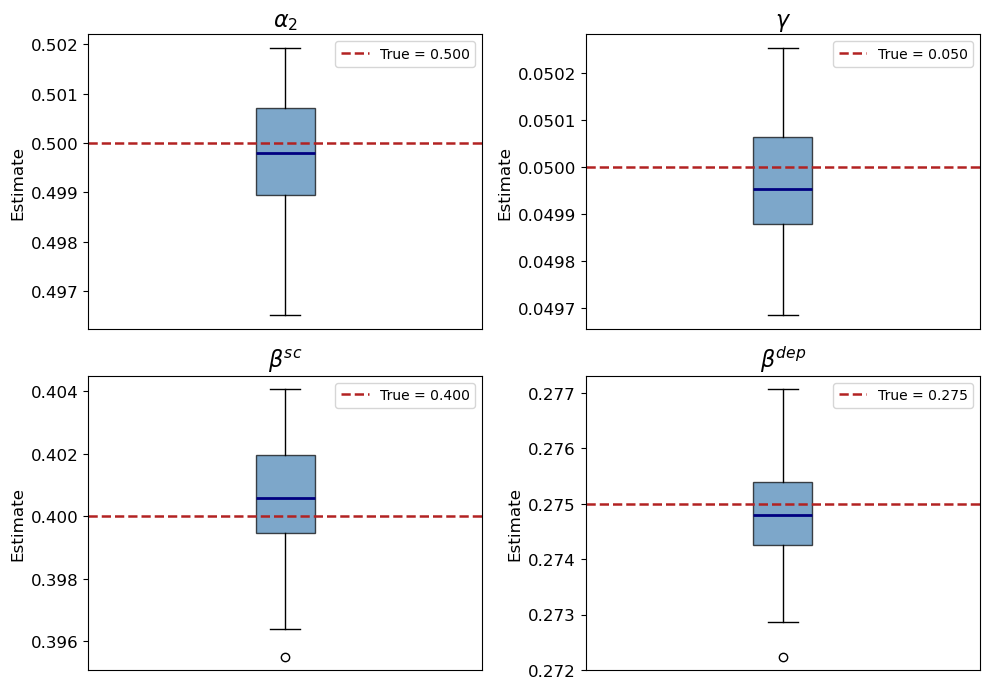

% Figure MC1: Distribution of Monte Carlo estimates
\begin{figure}[H]
    \centering
    \includegraphics[width=1\linewidth]{nfxp_mc_boxplots_original.pdf}
    \caption{Distribution of Monte Carlo estimates.}
    \label{fig:mc_estimate_distribution}
\end{figure}


In [15]:
# Making sure the Monte Carlo results are available before plotting
if "results" not in globals():
    raise RuntimeError("Run the Monte Carlo cell above before creating the figure.")

# LaTeX labels for each parameter used in plots.
latex_lbl = {
    "alpha_2": r"$\alpha_2$",
    "gamma": r"$\gamma$",
    "beta_sc": r"$\beta^{sc}$",
    "beta_dep": r"$\beta^{dep}$",
}

# Create one subplot for each estimated parameter.
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

# Plot the Monte Carlo distribution and true DGP value for each parameter.
for ax, (i, name) in zip(axes, enumerate(PARAM_NAMES)):
    est = results[results["param"] == name]["estimate"].to_numpy()
    true_v = THETA_TRUE[i]
    ax.boxplot(est, vert=True, patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.7),
               medianprops=dict(color="navy", linewidth=2))
    ax.axhline(true_v, color="firebrick", lw=1.8, ls="--",
               label=f"True = {true_v:.3f}")
    ax.set_title(latex_lbl.get(name, name), fontsize=16)
    ax.set_ylabel("Estimate", fontsize=12)
    ax.tick_params(axis="y", labelsize=12)
    ax.legend(fontsize=10)
    ax.xaxis.set_major_locator(mticker.NullLocator())

# Save the completed boxplot figure as a PDF and display it.
plt.tight_layout()
plt.savefig("nfxp_mc_boxplots_original.pdf", bbox_inches="tight")
plt.show()

# Adding LaTeX code to easily display the figure in the paper
figure_mc1_latex = r"""
\begin{figure}[H]
    \centering
    \includegraphics[width=1\linewidth]{nfxp_mc_boxplots_original.pdf}
    \caption{Distribution of Monte Carlo estimates.}
    \label{fig:mc_estimate_distribution}
\end{figure}
""".strip()

# Print the LaTeX snippet so the figure can be inserted into the paper.
print("% Figure MC1: Distribution of Monte Carlo estimates")
print(figure_mc1_latex)